In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("/home/zz1994/packages/ABCMB")
import jax
print(jax.devices()) 

ERROR:2026-02-03 22:23:13,988:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/ext3/miniforge3/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/ext3/miniforge3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/ext3/miniforge3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


[CpuDevice(id=0)]


In [4]:
from classy import Class
import jax.numpy as jnp
import numpy as np
from jax import jit, vmap, lax, grad, config, jacfwd
import equinox as eqx
import matplotlib.pyplot as plt
import time
import optimistix

from ABCMB import main, background, perturbations, spectrum, model_specs, species
from ABCMB import constants as cnst
from ABCMB import ABCMBTools as tools
from ABCMB.hyrex import hyrex

In [16]:
from pytests import accuracy_test

In [17]:
print(accuracy_test.test_accuracy_checker())


              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      

0.006623865498669893
0.007131396355895013
0.002293939446752983
None


# Setup

In [5]:
params = {
    'h': 0.7,
    'omega_cdm': 0.12,
    'omega_b': 0.0224,
    'A_s': 2.12424e-9,
    'n_s': 0.9709,
    'Neff': 3.044,
    'YHe': 0.245,
    'TCMB0': 2.34865418e-4,
    #'T_nu_massless' : 0.71636,
    #'N_nu_massless' : 3,
    'N_nu_massive': 0,
    'T_nu_massive': 0.71611,
    'm_nu_massive': 0.06,
    "tau_reion": 0.05461,
    #"z_reion" : 14.,
    "Delta_z_reion": 0.5,
    "z_reion_He": 3.5,
    "Delta_z_reion_He": 0.5,
}

"""
params = {
    #'h': jnp.asarray(0.9559548),
    'h': 0.9559548042757723,
    'omega_cdm': 0.1248880499490749,
    'omega_b': 0.02240954713694563,
    'A_s': 1.8498376165002644e-09,
    'n_s': 0.9621549615127597,
    'Neff': 3.044,
    #'YHe': 0.2,
    'TCMB0': 2.34865418e-4,
    #'T_nu_massless' : 0.71636,
    #'N_nu_massless' : 3,
    'N_nu_massive': 0,
    'T_nu_massive': 0.71611,
    'm_nu_massive': 0.06,
    "z_reion": 8.028497263851555,
    "Delta_z_reion": 0.5,
    "z_reion_He": 3.5,
    "Delta_z_reion_He": 0.5,
}
"""
"""
params = {
    'h': 0.6611+10.*0.0079,
    'omega_cdm': 0.1238+10*0.0021,
    'omega_b': 0.02259+10*0.00017,
    'A_s': 2.12e-9,
    'n_s': 0.9666+10.*0.0077,
    'Neff': 3.044,
    'TCMB0': 2.34865418e-4,
    #'T_nu_massless' : 0.71636,
    #'N_nu_massless' : 3,
    'N_nu_massive': 0,
    'T_nu_massive': 0.71611,
    'm_nu_massive': 0.06,
    "z_reion": 11.,
    "Delta_z_reion": 0.5,
    "z_reion_He": 3.5,
    "Delta_z_reion_He": 0.5,
}
"""

lmax = 4000
specs = {
    "output_Cl" : True,
    "l_max" : lmax,
    "lensing" : True,
    "output_Pk" : True,
    "output_k_max" : 0.5,
    #"bbn_type" : "table",
    "l_max_g" : 12,
    "l_max_pol_g" : 10,
    "l_max_ur" : 17,
    "l_max_ncdm" : 17,
    "output_background" : True,
    "output_perturbations" : True,
    "scale_sw" : 1.,
    "scale_isw" : 1.,
    "scale_dop" : 1.,
    "scale_pol" : 1.,
    "input_tau_reion" : True,
    "rtol_large_k_PE" : 1.e-3,
}
if params["N_nu_massive"] > 0:
    user_species = (
        species.MassiveNeutrino,
    )
else:
    user_species = None

#model = main.Model(user_species=user_species, input_specs=specs, return_PTBG=True, bbn_type="linX")
model = main.Model(user_species=user_species, input_specs=specs)

In [37]:
params = {
    'h': 0.7,
    'omega_cdm': 0.12,
    'omega_b': 0.0224,
    'A_s': 2.12424e-9,
    'n_s': 0.9709,
    'Neff': 3.044,
    'YHe': 0.245,
    'TCMB0': 2.34865418e-4,
    #'T_nu_massless' : 0.71636,
    #'N_nu_massless' : 3,
    'N_nu_massive': 0,
    'T_nu_massive': 0.71611,
    'm_nu_massive': 0.06,
    "tau_reion": 0.05461,
    #"z_reion" : 14.,
    "Delta_z_reion": 0.5,
    "z_reion_He": 3.5,
    "Delta_z_reion_He": 0.5,
}
for i in range(2):
    s = time.time()
    data, label = model.run_cosmology(params)
    print(time.time() - s)


              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      

164.60378909111023
14.314502477645874


In [27]:
params = label[-3]
PT = label[-2]
BG = label[-1]

In [10]:
n = 10
class_times = np.zeros(n)
for i in range(n):
    class_params = {
        "output": "mPk, tCl, pCl, lCl" if specs["lensing"] else "mPk, tCl, pCl",
        #"temperature_contributions" : "tsw",
        "P_k_max_1/Mpc" : specs["output_k_max"],
        "l_max_scalars" : lmax,
        "delta_l_max" : 500,
        "k_output_values" : "7.04886556e-06",
        "lensing" : "yes" if specs["lensing"] else "no",
        "accurate_lensing" : 1,
        "h": params["h"],
        "omega_b": params["omega_b"],
        "omega_cdm": params["omega_cdm"],
        "A_s" : params["A_s"],
        "n_s" : params["n_s"],
        "N_ur": 3.044,
        #"N_ur": 2.0308,
        "YHe": params["YHe"],
        #"YHe": 0.245,
        "N_ncdm": params["N_nu_massive"],
        "recombination" : "HyRec",
        #"reio_parametrization" : "reio_none",
        "reio_parametrization" : "reio_camb",
        "tau_reio" : params["tau_reion"],
        #"z_reio" : params["z_reion"],
        "reionization_width" : params["Delta_z_reion"],
        "helium_fullreio_redshift" : params["z_reion_He"],
        "helium_fullreio_width" : params["Delta_z_reion_He"],
        "reionization_exponent" : 1.5,
        "l_max_g": specs["l_max_g"],
        "l_max_pol_g": specs["l_max_pol_g"],
        "l_max_ur": specs["l_max_ur"], 
        "l_max_ncdm":specs["l_max_ncdm"],
        "radiation_streaming_trigger_tau_over_tau_k" : 20000,
        "radiation_streaming_trigger_tau_c_over_tau" : 2000,
        "ur_fluid_trigger_tau_over_tau_k" : 10000, 
        "ncdm_fluid_trigger_tau_over_tau_k" : 15000} 
    class_lcdm = Class()
    class_lcdm.set(class_params)
    if params["N_nu_massive"] > 0:
        class_lcdm.set({"m_ncdm": params["m_nu_massive"], "T_ncdm": params["T_nu_massive"]})
    s = time.time()
    class_lcdm.compute()
    rtime = time.time() - s
    print(rtime)
    class_times[i] = rtime

41.87770056724548
41.88882851600647
41.835989475250244
41.762190103530884
41.867928981781006
41.838568687438965
41.8538134098053
41.85525059700012
41.839425563812256
41.747787952423096


In [8]:
mean = np.mean(class_times)
sigma = np.sqrt(np.sum((class_times-mean)**2)/class_times.size)
print(mean)
print(sigma)

8.384218072891235
0.05424731330335676


In [62]:
mean2 = np.mean(class_times2)
sigma2 = np.sqrt(np.sum((class_times2-mean2)**2)/class_times2.size)
print(mean2)
print(sigma2)

25.993018245697023
0.03971500048926677


In [6]:
class_params = {
    "output": "mPk, tCl, pCl, lCl",
    "k_output_values" : "7.04886556e-06",
    "lensing" : "yes",
    "accurate_lensing" : 1,
    "h": params["h"],
    "omega_b": params["omega_b"],
    "omega_cdm": params["omega_cdm"],
    "A_s" : params["A_s"],
    "n_s" : params["n_s"],
    "N_ur": 3.044,
    #"N_ur": 2.0308,
    "YHe": params["YHe"],
    #"YHe": 0.245,
    "N_ncdm": params["N_nu_massive"],
    "recombination" : "HyRec",
    #"reio_parametrization" : "reio_none",
    "reio_parametrization" : "reio_camb",
    "tau_reio" : params["tau_reion"],
    #"z_reio" : params["z_reion"],
    "reionization_width" : params["Delta_z_reion"],
    "helium_fullreio_redshift" : params["z_reion_He"],
    "helium_fullreio_width" : params["Delta_z_reion_He"],
    "reionization_exponent" : 1.5,
    "l_max_g": specs["l_max_g"],
    "l_max_pol_g": specs["l_max_pol_g"],
    "l_max_ur": specs["l_max_ur"], 
    "l_max_ncdm":specs["l_max_ncdm"],}

In [7]:
ls = np.array([1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500])
ts = np.zeros(ls.size)
for i, l in enumerate(ls):
    class_lcdm = Class()
    class_lcdm.set(class_params)
    class_lcdm.set({"l_max_scalars" : l})
    s = time.time()
    class_lcdm.compute()
    rtime = time.time() - s
    print(rtime)
    ts[i] = rtime

4.084166526794434
4.381028175354004
5.075141668319702
5.966224431991577
6.828052759170532
7.7343831062316895
8.817694425582886
10.043225526809692


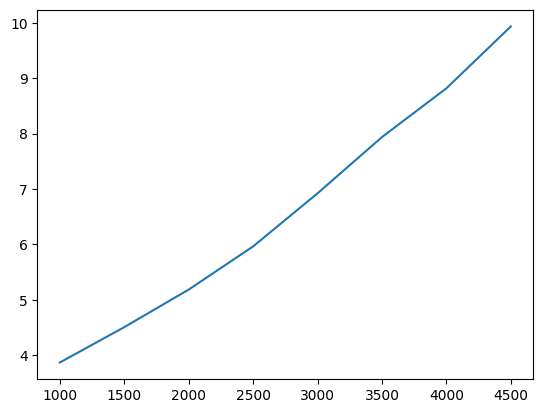

In [15]:
plt.plot(ls, ts)
plt.show()

# Params Check

In [96]:
### RNG ###
# Randomly generate values given RNG key and bounds for each params.
def sample_lcdm_params(key, bounds_dict):
    keys = list(bounds_dict.keys())
    lows  = jnp.array([bounds_dict[k][0] for k in keys])
    highs = jnp.array([bounds_dict[k][1] for k in keys])

    u = jax.random.uniform(key, shape=(len(keys),))
    sample = lows + u * (highs - lows)

    return {k: sample[i] for i, k in enumerate(keys)}

#Lower and upper bounds

bounds = {
    'h': (0.5, 1.0),
    #'h' : (0.6, 0.8),
    'omega_cdm': (0.1198-5*0.0012, 0.1198+5*0.0012),
    'omega_b': (0.02233-5*0.00015, 0.02233+5*0.00015),
    'A_s': (2.09680531e-9-5*1.0140985e-10, 2.09680531e-9+5*1.0140985e-10),
    'n_s': (0.9652-5*0.0042, 0.9652+5*0.0042),
    'z_reion': (5., 15.),
}

### ABCMB Setup ###
specs = {
    "l_max" : 2500,
    "output_Cl" : True,
    "lensing" : False,
    "output_Pk" : True,
    "output_k_max" : 0.5,
    "bbn_type" : "table",
    "l_max_g" : 12,
    "l_max_pol_g" : 10,
    "l_max_ur" : 17,
    "l_max_ncdm" : 17,
    "scale_sw" : 1.,
    "scale_isw" : 1.,
    "scale_dop" : 1.,
    "scale_pol" : 1.
}
ABCMB_fixed = {
    'Neff' : 3.044,
    'N_nu_massive': 0,
    'T_nu_massive': 0.71611,
    'm_nu_massive': 0.06,
    "Delta_z_reion": 0.5,
    "z_reion_He": 3.5,
    "Delta_z_reion_He": 0.5
}
if ABCMB_fixed["N_nu_massive"] > 0:
    user_species = (
        species.MassiveNeutrino,
    )
else:
    user_species = None

ABCMB_lcdm = main.Model(specs, user_species)

### SET UP CLASS ###
class_fixed = {
    "output": "mPk, tCl, pCl, lCl" if specs["lensing"] else "mPk, tCl, pCl",
    #"temperature_contributions" : "tsw",
    "P_k_max_1/Mpc" : specs["output_k_max"],
    "l_max_scalars" : lmax,
    "k_output_values" : "7.04886556e-06",
    "lensing" : "yes" if specs["lensing"] else "no",
    "accurate_lensing" : 0,
    "N_ur": params["Neff"],
    #"N_ur": 2.0308,
    #"YHe": params["YHe"],
    "YHe": "bbn",
    "N_ncdm": params["N_nu_massive"],
    #"reio_parametrization" : "reio_none",
    "reio_parametrization" : "reio_camb",
    "reionization_width" : params["Delta_z_reion"],
    "helium_fullreio_redshift" : params["z_reion_He"],
    "helium_fullreio_width" : params["Delta_z_reion_He"],
    "reionization_exponent" : 1.5,
    "l_max_g": specs["l_max_g"],
    "l_max_pol_g": specs["l_max_pol_g"],
    "l_max_ur": specs["l_max_ur"], 
    "l_max_ncdm":specs["l_max_ncdm"]
} 
if ABCMB_fixed["N_nu_massive"] > 0:
    class_fixed = class_fixed | {"m_ncdm": ABCMB_fixed["m_nu_massive"], "T_ncdm": ABCMB_fixed["T_nu_massive"]}
class_lcdm = Class()

### BEGINNING OF TEST ###

tt_max_err = np.zeros(ABCMB_lcdm.SS.ells.size)
ee_max_err = np.zeros(ABCMB_lcdm.SS.ells.size)
Pk_max_err = np.zeros(ABCMB_lcdm.SS.k_axis_Pk_output.size)
for i in range(1):
    # Generate parameters
    key = jax.random.PRNGKey(i+8)
    ABCMB_rand = sample_lcdm_params(key, bounds)
    ABCMB_params = ABCMB_rand | ABCMB_fixed
    class_params = class_fixed.copy()
    #class_params["H0"] = ABCMB_params["h"]*100
    class_params["h"] = ABCMB_params["h"]
    #class_params["h"] = 0.9559548
    class_params["omega_b"] = ABCMB_params["omega_b"]
    class_params["omega_cdm"] = ABCMB_params["omega_cdm"]
    class_params["A_s"] = ABCMB_params["A_s"]
    class_params["n_s"] = ABCMB_params["n_s"]
    class_params["z_reio"] = ABCMB_params["z_reion"]
    class_lcdm.set(class_params)

    # Run ABCMB
    s = time.time()
    output, aux = ABCMB_lcdm.run_cosmology(ABCMB_params)
    l = aux[0]
    k = aux[1]
    tt = output[0]
    ee = output[2]
    Pk = output[3]

    # Run class
    class_lcdm.compute()
    if specs["lensing"]:
        class_tt = class_lcdm.lensed_cl(l[-1])["tt"][2:]
        class_ee = class_lcdm.lensed_cl(l[-1])["ee"][2:]
    else:
        class_tt = class_lcdm.raw_cl(l[-1])["tt"][2:]
        class_ee = class_lcdm.raw_cl(l[-1])["ee"][2:]
    class_Pk = np.vectorize(class_lcdm.pk)(k, 0)

    # update error
    tt_max_err = np.maximum(tt_max_err, abs(tt/class_tt - 1.))
    ee_max_err = np.maximum(ee_max_err, abs(ee/class_ee - 1.))
    Pk_max_err = np.maximum(Pk_max_err, abs(Pk/class_Pk - 1.))
    print(ABCMB_rand)
    print(tt_max_err.max())
    print(ee_max_err.max())

{'h': Array(0.9559548, dtype=float64), 'omega_cdm': Array(0.12488805, dtype=float64), 'omega_b': Array(0.02240955, dtype=float64), 'A_s': Array(1.84983762e-09, dtype=float64), 'n_s': Array(0.96215496, dtype=float64), 'z_reion': Array(8.02849726, dtype=float64)}
0.007900449687082145
0.009742376521899687


In [97]:
### RNG ###
# Randomly generate values given RNG key and bounds for each params.
def sample_lcdm_params(key, bounds_dict):
    keys = list(bounds_dict.keys())
    lows  = jnp.array([bounds_dict[k][0] for k in keys])
    highs = jnp.array([bounds_dict[k][1] for k in keys])

    u = jax.random.uniform(key, shape=(len(keys),))
    sample = lows + u * (highs - lows)

    return {k: jnp.asarray(sample[i], dtype=jnp.float64) for i, k in enumerate(keys)}

#Lower and upper bounds

bounds = {
    'h': (0.5, 1.0),
    #'h' : (0.6, 0.8),
    'omega_cdm': (0.1198-5*0.0012, 0.1198+5*0.0012),
    'omega_b': (0.02233-5*0.00015, 0.02233+5*0.00015),
    'A_s': (2.09680531e-9-5*1.0140985e-10, 2.09680531e-9+5*1.0140985e-10),
    'n_s': (0.9652-5*0.0042, 0.9652+5*0.0042),
    'z_reion': (5., 15.),
}

### ABCMB Setup ###
specs = {
    "l_max" : 2500,
    "output_Cl" : True,
    "lensing" : False,
    "output_Pk" : True,
    "output_k_max" : 0.5,
    "bbn_type" : "table",
    "l_max_g" : 12,
    "l_max_pol_g" : 10,
    "l_max_ur" : 17,
    "l_max_ncdm" : 17,
    "scale_sw" : 1.,
    "scale_isw" : 1.,
    "scale_dop" : 1.,
    "scale_pol" : 1.
}
ABCMB_fixed = {
    'Neff' : 3.044,
    'N_nu_massive': 0,
    'T_nu_massive': 0.71611,
    'm_nu_massive': 0.06,
    "Delta_z_reion": 0.5,
    "z_reion_He": 3.5,
    "Delta_z_reion_He": 0.5
}
if ABCMB_fixed["N_nu_massive"] > 0:
    user_species = (
        species.MassiveNeutrino,
    )
else:
    user_species = None

ABCMB_lcdm = main.Model(specs, user_species)

### SET UP CLASS ###
class_fixed = {
    "output": "mPk, tCl, pCl, lCl" if specs["lensing"] else "mPk, tCl, pCl",
    #"temperature_contributions" : "tsw",
    "P_k_max_1/Mpc" : specs["output_k_max"],
    "l_max_scalars" : lmax,
    "k_output_values" : "7.04886556e-06",
    "lensing" : "yes" if specs["lensing"] else "no",
    "accurate_lensing" : 0,
    "N_ur": params["Neff"],
    #"N_ur": 2.0308,
    #"YHe": params["YHe"],
    "YHe": "bbn",
    "N_ncdm": params["N_nu_massive"],
    #"reio_parametrization" : "reio_none",
    "reio_parametrization" : "reio_camb",
    "reionization_width" : params["Delta_z_reion"],
    "helium_fullreio_redshift" : params["z_reion_He"],
    "helium_fullreio_width" : params["Delta_z_reion_He"],
    "reionization_exponent" : 1.5,
    "l_max_g": specs["l_max_g"],
    "l_max_pol_g": specs["l_max_pol_g"],
    "l_max_ur": specs["l_max_ur"], 
    "l_max_ncdm":specs["l_max_ncdm"]
} 
if ABCMB_fixed["N_nu_massive"] > 0:
    class_fixed = class_fixed | {"m_ncdm": ABCMB_fixed["m_nu_massive"], "T_ncdm": ABCMB_fixed["T_nu_massive"]}
class_lcdm = Class()

### BEGINNING OF TEST ###

tt_max_err = np.zeros(ABCMB_lcdm.SS.ells.size)
ee_max_err = np.zeros(ABCMB_lcdm.SS.ells.size)
Pk_max_err = np.zeros(ABCMB_lcdm.SS.k_axis_Pk_output.size)
for i in range(1):
    # Generate parameters
    ABCMB_rand = {'h': 0.9559548, 
                  'omega_cdm': 0.12488805, 
                  'omega_b': 0.02240955, 
                  'A_s': 1.84983762e-09, 
                  'n_s': 0.96215496, 
                  'z_reion': 8.02849726}
    ABCMB_params = ABCMB_rand | ABCMB_fixed
    class_params = class_fixed.copy()
    #class_params["H0"] = ABCMB_params["h"]*100
    class_params["h"] = ABCMB_params["h"]
    #class_params["h"] = 0.9559548
    class_params["omega_b"] = ABCMB_params["omega_b"]
    class_params["omega_cdm"] = ABCMB_params["omega_cdm"]
    class_params["A_s"] = ABCMB_params["A_s"]
    class_params["n_s"] = ABCMB_params["n_s"]
    class_params["z_reio"] = ABCMB_params["z_reion"]
    class_lcdm.set(class_params)

    # Run ABCMB
    s = time.time()
    output, aux = ABCMB_lcdm.run_cosmology(ABCMB_params)
    l = aux[0]
    k = aux[1]
    tt = output[0]
    ee = output[2]
    Pk = output[3]

    # Run class
    class_lcdm.compute()
    if specs["lensing"]:
        class_tt = class_lcdm.lensed_cl(l[-1])["tt"][2:]
        class_ee = class_lcdm.lensed_cl(l[-1])["ee"][2:]
    else:
        class_tt = class_lcdm.raw_cl(l[-1])["tt"][2:]
        class_ee = class_lcdm.raw_cl(l[-1])["ee"][2:]
    class_Pk = np.vectorize(class_lcdm.pk)(k, 0)

    # update error
    tt_max_err = np.maximum(tt_max_err, abs(tt/class_tt - 1.))
    ee_max_err = np.maximum(ee_max_err, abs(ee/class_ee - 1.))
    Pk_max_err = np.maximum(Pk_max_err, abs(Pk/class_Pk - 1.))
    print(ABCMB_params)
    print(tt_max_err.max())
    print(ee_max_err.max())

{'h': 0.9559548, 'omega_cdm': 0.12488805, 'omega_b': 0.02240955, 'A_s': 1.84983762e-09, 'n_s': 0.96215496, 'z_reion': 8.02849726, 'Neff': 3.044, 'N_nu_massive': 0, 'T_nu_massive': 0.71611, 'm_nu_massive': 0.06, 'Delta_z_reion': 0.5, 'z_reion_He': 3.5, 'Delta_z_reion_He': 0.5}
0.00775119936196389
0.008869420514920678


In [98]:
script = class_ee

In [99]:
abs(nb/script - 1.).max()

np.float64(0.0)

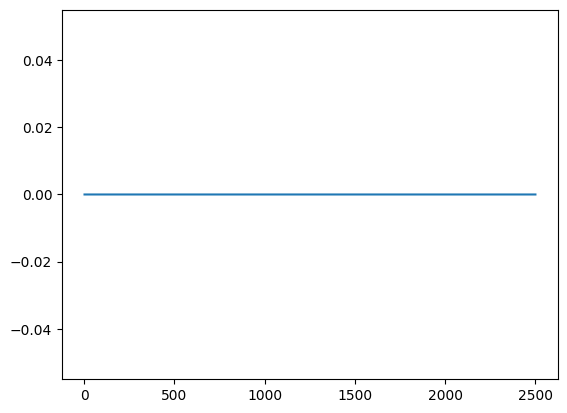

In [100]:
plt.plot(l, nb/script - 1.)
plt.show()

# Background Check

## Hubble

In [212]:
class_bg = class_lcdm.get_background()
BG = label[4]
a = 1/(1.+class_bg["z"])
H_class = class_bg['H [1/Mpc]'] * cnst.c_Mpc_over_s
H_ABCMB = BG.H(jnp.log(a), params)
plt.plot(a, abs(H_class - H_ABCMB)/H_class)
plt.yscale("symlog")
plt.xscale("log")
plt.show()

KeyError: 'omega_Lambda'

## Massive Neutrino Density

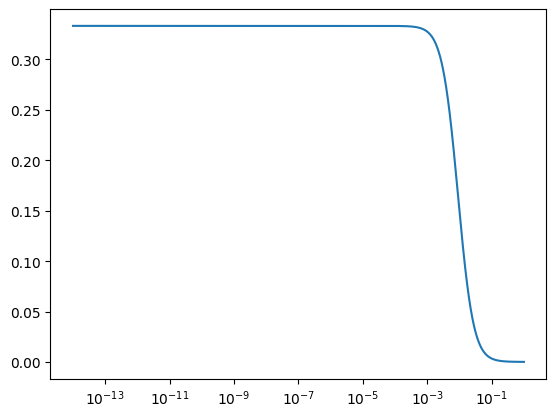

In [15]:
rho_nu_class = class_bg[ '(.)p_ncdm[0]']/class_bg[ '(.)rho_ncdm[0]']
plt.plot(a, rho_nu_class)
#rho_nu_ABCMB = BG.H(jnp.log(a), params)
#plt.plot(a, (H_class - H_ABCMB)/H_class)
#plt.yscale("symlog")
#plt.xscale("log")
#plt.xlim((1.e-5, 1.))
plt.xscale("log")
plt.show()

# Thermodynamics Check

In [22]:
path = "/home/zz1994/packages/HYREC-2"
hyrec_dat = np.loadtxt(path+"/test_full.dat")

In [23]:
z_hyrec = hyrec_dat[:, 0]
lna_hyrec = jnp.log(1/(1+z_hyrec))
xe_hyrec = hyrec_dat[:, 1]

In [24]:
xe_abcmb = BG.xe(lna_hyrec)

plt.plot(lna_hyrec, xe_abcmb)
plt.plot(lna_hyrec, xe_hyrec, "--")
#plt.ylim((1.e-4, 1.e-3))
#plt.xlim((-2, 0))
plt.yscale("log")
#plt.xscale("log")
plt.show()

plt.plot(lna_hyrec, abs(xe_abcmb-xe_hyrec)/xe_hyrec)
plt.yscale("log")
#plt.xscale("log")
plt.axhline(1.e-3, ls="--", color="black")
plt.xlabel(r"$\ln{a}$")
plt.title("xe fractional error")
#plt.ylim((1.e-3, 1.e-2))
plt.show()


NameError: name 'BG' is not defined

In [25]:
lna_class

Array([-1.54249487e+01, -1.54237055e+01, -1.54224623e+01, ...,
       -2.95617151e-02, -1.48900905e-02,  0.00000000e+00], dtype=float64)

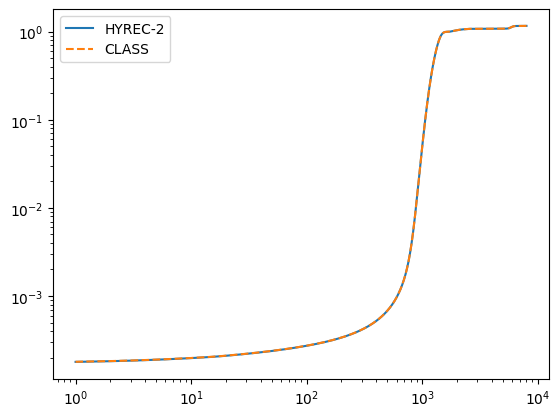

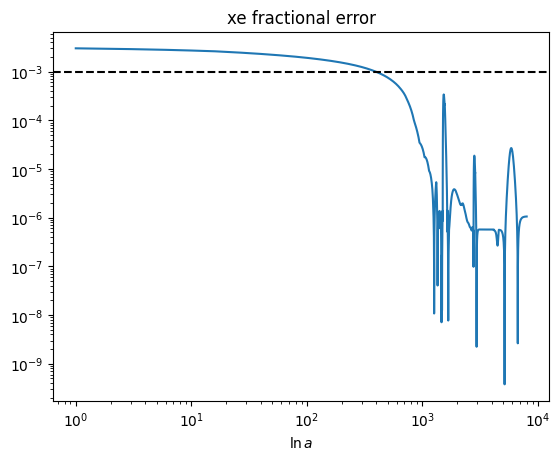

In [28]:
class_rec = class_lcdm.get_thermodynamics()
lna_class = jnp.flip(jnp.log(1/(1.+class_rec["z"])))
xe_class = jnp.flip(class_rec["x_e"])
xe_class_interp = jnp.interp(lna_hyrec, lna_class, xe_class)

plt.plot(z_hyrec, xe_hyrec, label="HYREC-2")
plt.plot(z_hyrec, xe_class_interp, "--", label="CLASS")
#plt.ylim((1.e-4, 1.e-3))
#plt.xlim((-2, 0))
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.show()


plt.plot(z_hyrec, abs(xe_class_interp-xe_hyrec)/xe_hyrec)
plt.yscale("log")
plt.xscale("log")
plt.axhline(1.e-3, ls="--", color="black")
plt.xlabel(r"$\ln{a}$")
plt.title("xe fractional error")
#plt.ylim((1.e-3, 1.e-2))
plt.show()


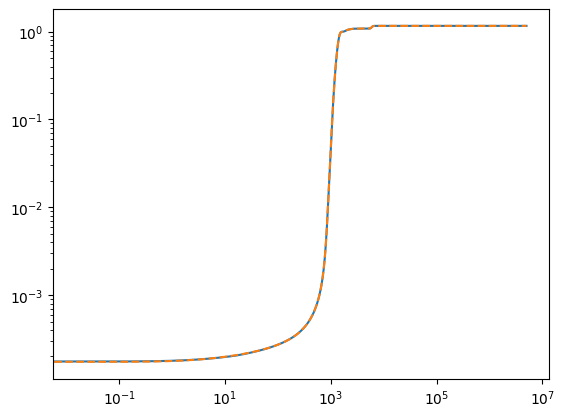

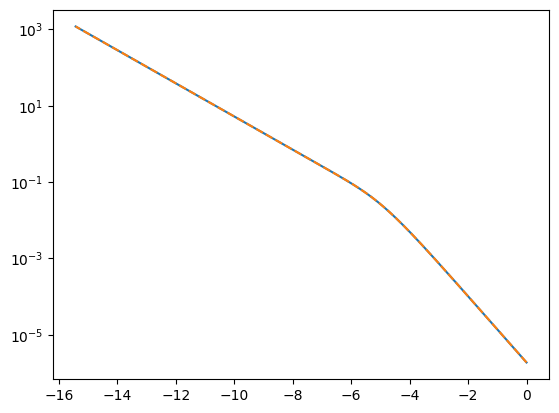

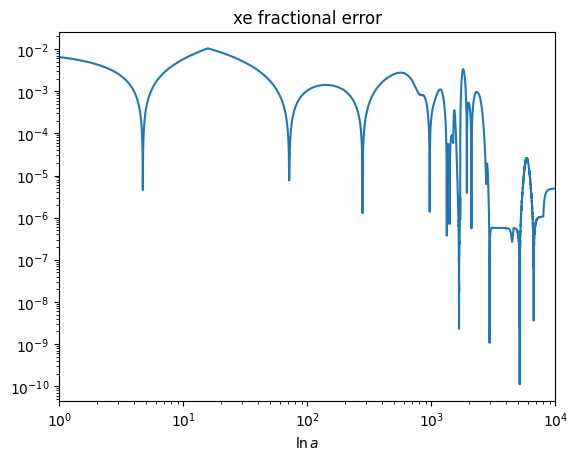

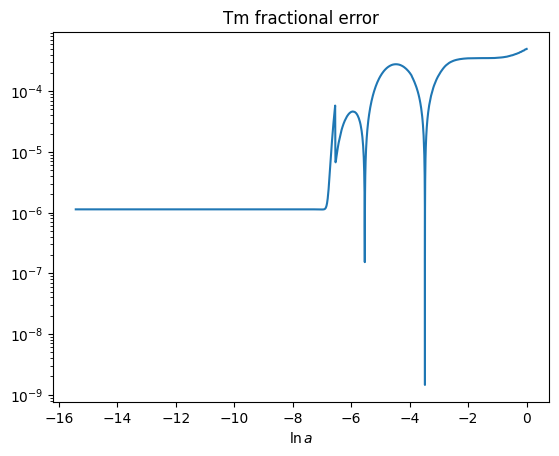

In [51]:
class_rec = class_lcdm.get_thermodynamics()
a = 1/(1.+class_rec["z"])
xe_class = class_rec["x_e"]
Tm_class = class_rec['Tb [K]'] * cnst.kB
xe_abcmb = BG.xe(jnp.log(a))
Tm_abcmb = BG.Tm(jnp.log(a), params)

plt.plot(1/a-1, xe_abcmb)
plt.plot(1/a-1, xe_class, "--")
#plt.ylim((1.e-4, 1.e-3))
#plt.xlim((-2, 0))
plt.yscale("log")
plt.xscale("log")
plt.show()

plt.plot(jnp.log(a), Tm_abcmb)
plt.plot(jnp.log(a), Tm_class, "--")
plt.yscale("log")
plt.show()

plt.plot(1/a-1, abs(xe_abcmb-xe_class)/xe_class)
plt.yscale("log")
plt.xscale("log")
plt.xlabel(r"$\ln{a}$")
plt.title("xe fractional error")
#plt.ylim((1.e-3, 1.e-2))
plt.xlim((1, 1e))
plt.show()

plt.plot(jnp.log(a), abs(Tm_abcmb-Tm_class)/Tm_class)
plt.yscale("log")
plt.xlabel(r"$\ln{a}$")
#plt.xlim((-8, -6))
plt.title("Tm fractional error")
plt.show()

In [43]:
expmkappa_class = class_rec["exp(-kappa)"]
g_class = class_rec["g [Mpc^-1]"]
expmkappa_abcmb = vmap(BG.expmkappa)(jnp.log(a))
g_abcmb = vmap(BG.visibility, in_axes=(0, None))(jnp.log(a), params)

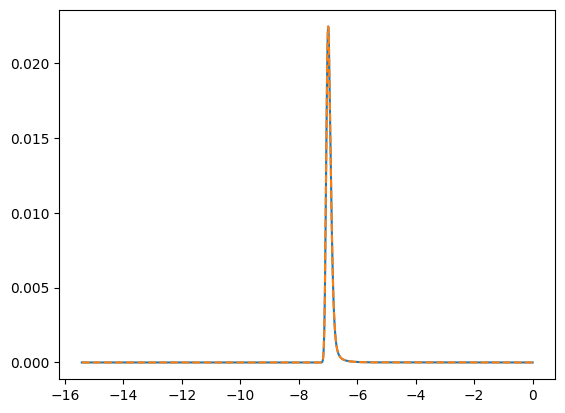

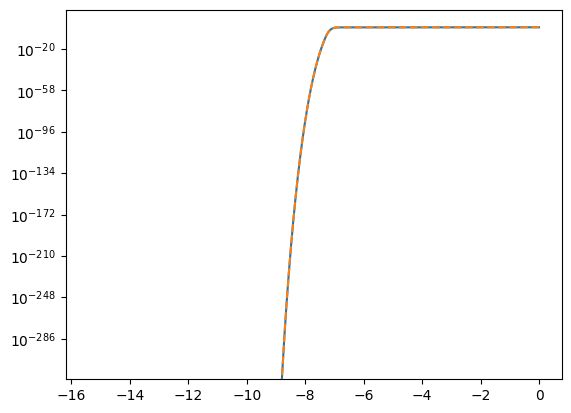

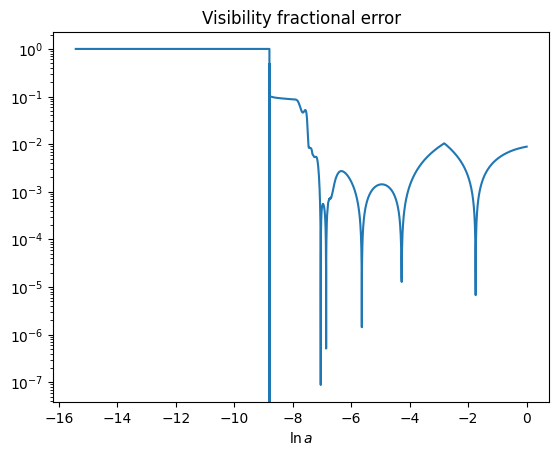

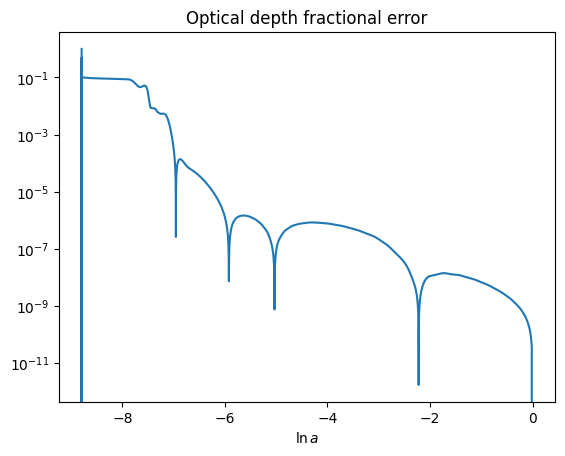

In [44]:
plt.plot(jnp.log(a), g_abcmb)
plt.plot(jnp.log(a), g_class, "--")
plt.show()

plt.plot(jnp.log(a), expmkappa_abcmb)
plt.plot(jnp.log(a), expmkappa_class, "--")
plt.yscale("log")
plt.show()

plt.plot(jnp.log(a), abs(g_abcmb-g_class)/g_class)
plt.yscale("log")
plt.xlabel(r"$\ln{a}$")
plt.title("Visibility fractional error")
#plt.xlim((-8, -6))
plt.show()

plt.plot(jnp.log(a), abs(expmkappa_abcmb-expmkappa_class)/expmkappa_class)
plt.yscale("log")
plt.xlabel(r"$\ln{a}$")
#plt.xlim((-8, -6))
plt.title("Optical depth fractional error")
plt.show()

# Perturbations Check

In [80]:
class_pert = class_lcdm.get_perturbations()

In [81]:
cp = class_pert["scalar"][0]

In [82]:
cp.keys()

dict_keys(['tau [Mpc]', 'a', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'delta_ur', 'theta_ur', 'shear_ur', 'delta_cdm', 'theta_cdm'])

In [112]:
lna_class = jnp.log(cp["a"])
source_class = 2.*cp["shear_g"] + cp["pol0_g"] + cp["pol2_g"]
source_class = jnp.interp(PT.lna, lna_class, source_abcmb)

In [113]:
source_abcmb = 2.*PT.sigma_g[:, 0] + PT.Gg0[:, 0] + PT.Gg2[:, 0]

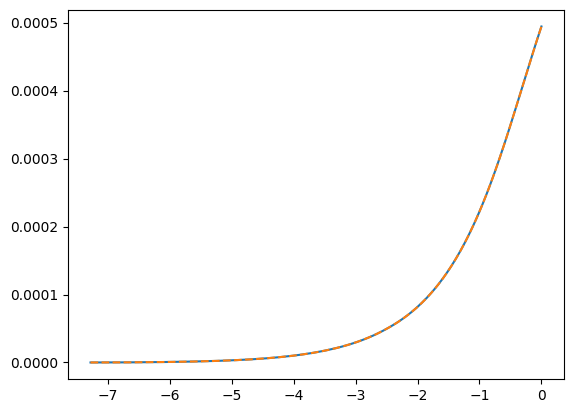

In [114]:
plt.plot(PT.lna, source_class)
plt.plot(PT.lna, source_abcmb, "--")
plt.show()

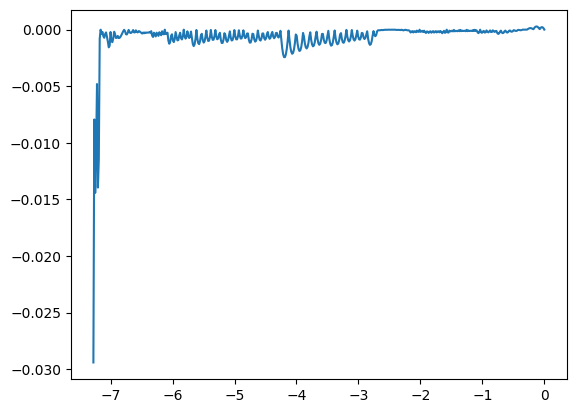

In [115]:
plt.plot(PT.lna, source_abcmb/source_class - 1.)
plt.show()

# Cl's

In [54]:
if specs["lensing"]:
    class_ell = class_lcdm.lensed_cl(lmax)["ell"]
    class_tt = class_lcdm.lensed_cl(lmax)["tt"] * class_ell * (class_ell+1)/2./jnp.pi
    class_te = class_lcdm.lensed_cl(lmax)["te"] * class_ell * (class_ell+1)/2./jnp.pi
    class_ee = class_lcdm.lensed_cl(lmax)["ee"] * class_ell * (class_ell+1)/2./jnp.pi

else:
    class_ell = class_lcdm.raw_cl(lmax)["ell"]
    class_tt = class_lcdm.raw_cl(lmax)["tt"] * class_ell * (class_ell+1)/2./jnp.pi
    class_te = class_lcdm.raw_cl(lmax)["te"] * class_ell * (class_ell+1)/2./jnp.pi
    class_ee = class_lcdm.raw_cl(lmax)["ee"] * class_ell * (class_ell+1)/2./jnp.pi

ells = label[0]
abcmb_tt = ells*(ells+1)/2./jnp.pi * data[0]
abcmb_te = ells*(ells+1)/2./jnp.pi * data[1]
abcmb_ee = ells*(ells+1)/2./jnp.pi * data[2]

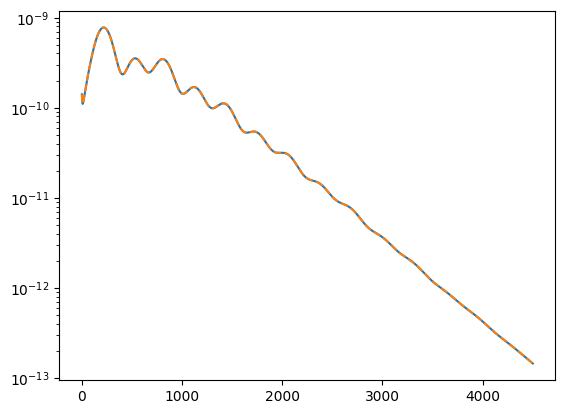

In [55]:
full_l = model.SS.ells
plt.plot(full_l, abcmb_tt)
plt.plot(full_l, class_tt[2:], "--")
plt.yscale("log")
#plt.xlim((3500, 4500))
#plt.ylim((1.e-13, 5.e-12))
plt.show()

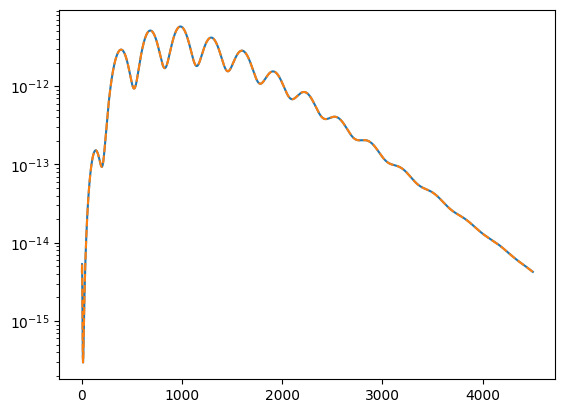

In [56]:
full_l = model.SS.ells
plt.plot(full_l, abcmb_ee)
plt.plot(full_l, class_ee[2:], "--")
plt.yscale("log")
plt.show()

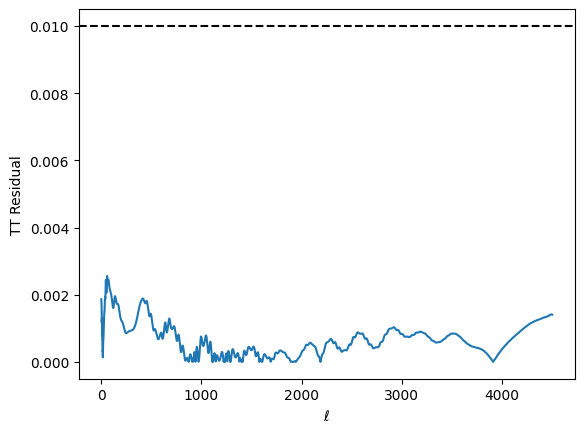

In [57]:
err = abs(abcmb_tt/class_tt[2:] - 1.)
plt.plot(full_l, err)
plt.axhline(0.01, ls="--", color="black")
plt.xlabel(r"$\ell$")
plt.ylabel("TT Residual")
#plt.yscale("log")
#plt.xscale("log")
plt.show()

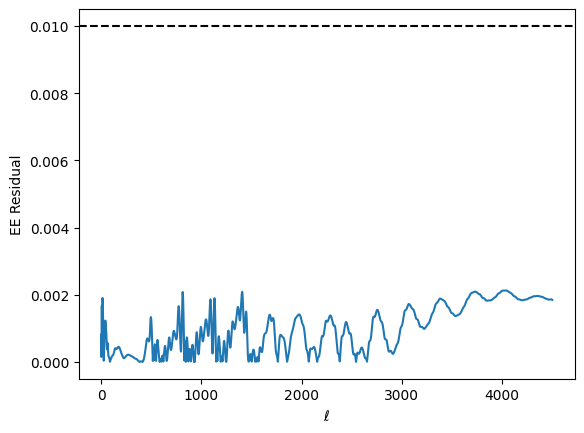

In [43]:
err = abs(abcmb_ee/class_ee[2:] - 1.)
plt.plot(full_l, err)
plt.axhline(0.01, ls="--", color="black")
plt.xlabel(r"$\ell$")
plt.ylabel("EE Residual")
#plt.yscale("log")
#plt.xscale("log")
plt.show()

In [16]:
err.max()

Array(0.00208301, dtype=float64)

In [84]:
from typing import Tuple

def _legendre_pn_and_pnm1(z: jnp.ndarray, n: int) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    Compute P_n(z) and P_{n-1}(z) for vector z using the standard recurrence.
    z: shape (m,)
    Returns: (P_n(z), P_{n-1}(z)) each shape (m,)
    """
    # Match your C init:
    # p1 -> current P_j
    # p2 -> previous P_{j-1}
    p1 = jnp.ones_like(z)     # P_0
    p2 = jnp.zeros_like(z)    # P_{-1} (not used, but matches recurrence init)

    # Recurrence:
    # P_j = ((2j-1) z P_{j-1} - (j-1) P_{j-2}) / j
    for j in range(1, n + 1):
        p3 = p2
        p2 = p1
        p1 = ((2.0 * j - 1.0) * z * p2 - (j - 1.0) * p3) / j

    # After loop: p1 = P_n, p2 = P_{n-1}
    return p1, p2


def gauss_legendre_nodes_weights_jax(n: int, tol: float, max_it: int = 50,
                                    dtype=jnp.float64) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    Compute Gauss-Legendre nodes (mu) and weights (w) on [-1, 1], mirroring your C routine.
    Vectorized Newton iterations over half the roots.
    Called outside JIT; uses Python loops for iteration.
    """
    if n <= 0:
        raise ValueError("n must be positive")

    # Enable 64-bit in JAX if you care about high-accuracy quadrature
    # (you can also set JAX_ENABLE_X64=1 in env).
    # Here we assume you have x64 enabled if you pass float64.

    m = (n + 1) // 2
    i = jnp.arange(1, m + 1, dtype=dtype)

    # Initial guess: z = cos(pi*(i-0.25)/(n+0.5))
    z = jnp.cos(jnp.array(jnp.pi, dtype=dtype) * (i - 0.25) / (n + 0.5))

    # Newton iterations (vectorized across z)
    for _ in range(max_it):
        p_n, p_nm1 = _legendre_pn_and_pnm1(z, n)

        # pp = P_n'(z) = n*(z*P_n - P_{n-1})/(z^2 - 1)
        pp = n * (z * p_n - p_nm1) / (z * z - 1.0)

        z_new = z - p_n / pp

        # convergence check: max |Δz|
        if float(jnp.max(jnp.abs(z_new - z))) <= tol:
            z = z_new
            break
        z = z_new
    else:
        raise RuntimeError(
            f"Gauss-Legendre Newton iterations did not converge in {max_it} steps "
            f"(n={n}, tol={tol}). Increase max_it or relax tol."
        )

    # After convergence, compute derivative again for weights
    p_n, p_nm1 = _legendre_pn_and_pnm1(z, n)
    pp = n * (z * p_n - p_nm1) / (z * z - 1.0)

    w_half = 2.0 / ((1.0 - z * z) * pp * pp)

    # Build full nodes/weights by symmetry:
    # mu[i-1] = -z, mu[n-i] = z
    # w same mirrored
    mu = jnp.empty((n,), dtype=dtype)
    w = jnp.empty((n,), dtype=dtype)

    mu = mu.at[:m].set(-z[::-1] if (n % 2 == 0) else -z[::-1])  # left half (negative)
    mu = mu.at[n - m:].set(z)                                   # right half (positive)

    # For nodes, the ordering above gives:
    # left half increasing from negative to ... (depends on reverse)
    # If you want EXACT C layout (mu[i-1]=-z with i ascending), use:
    #   mu[:m] = -z
    #   mu[n-m:] = z[::-1]
    #
    # Let's match the C layout exactly:
    mu = jnp.empty((n,), dtype=dtype)
    mu = mu.at[:m].set(-z)            # i=1..m => mu[i-1]
    mu = mu.at[n - m:].set(z[::-1])   # i=1..m => mu[n-i]

    w = jnp.empty((n,), dtype=dtype)
    w = w.at[:m].set(w_half)
    w = w.at[n - m:].set(w_half[::-1])

    return mu, w


In [96]:
def quad(f, mu, w):
    return jnp.sum(w * f(mu))

n = 70+4500
mu, w = gauss_legendre_jax(n, tol=1e-10)

# ∫_{-1}^1 x^4 dx = 2/5 = 0.4
val = quad(lambda x: x**4, mu, w)
print(val, float(val) - 0.4)

0.39999999999999925 -7.771561172376096e-16


In [97]:
mu

Array([-0.99999986, -0.99999927, -0.99999821, ...,  0.99999821,
        0.99999927,  0.99999986], dtype=float64)

In [91]:
def _pn_and_pnm1_scan(z, n):
    """Return P_n(z), P_{n-1}(z) for vector z using lax.scan."""
    z = jnp.asarray(z)
    p1 = jnp.ones_like(z)      # P_0
    p2 = jnp.zeros_like(z)     # P_{-1} (dummy)

    def step(carry, j):
        p1, p2 = carry
        # recurrence:
        # new_p1 = P_j, new_p2 = P_{j-1}
        new_p1 = ((2.0*j - 1.0) * z * p1 - (j - 1.0) * p2) / j
        new_p2 = p1
        return (new_p1, new_p2), None

    (p_n, p_nm1), _ = lax.scan(step, (p1, p2), jnp.arange(1, n+1))
    return p_n, p_nm1

def gauss_legendre(n: int, tol: float, max_it: int = 50, dtype=jnp.float64):
    m = (n + 1) // 2
    i = jnp.arange(1, m + 1, dtype=dtype)
    z0 = jnp.cos(jnp.array(jnp.pi, dtype=dtype) * (i - 0.25) / (n + 0.5))

    def newton_step(z):
        p_n, p_nm1 = _pn_and_pnm1_scan(z, n)
        pp = n * (z * p_n - p_nm1) / (z*z - 1.0)  # P_n'(z)
        z_new = z - p_n / pp
        return z_new, jnp.max(jnp.abs(z_new - z)), pp

    def cond(state):
        z, err, it = state
        return jnp.logical_and(err > tol, it < max_it)

    def body(state):
        z, err, it = state
        z_new, err_new, _ = newton_step(z)
        return (z_new, err_new, it + 1)

    # init
    z1, err1, _ = newton_step(z0)
    z, err, it = lax.while_loop(cond, body, (z1, err1, jnp.array(1)))

    # final derivative for weights
    p_n, p_nm1 = _pn_and_pnm1_scan(z, n)
    pp = n * (z * p_n - p_nm1) / (z*z - 1.0)
    w_half = 2.0 / ((1.0 - z*z) * pp * pp)

    # match your C layout: mu[i-1] = -z(i), mu[n-i] = z(i)
    mu = jnp.empty((n,), dtype=dtype)
    w  = jnp.empty((n,), dtype=dtype)
    mu = mu.at[:m].set(-z)
    mu = mu.at[n-m:].set(z[::-1])
    w  = w.at[:m].set(w_half)
    w  = w.at[n-m:].set(w_half[::-1])

    return mu, w


# Lensing

## Lensing Cl

In [30]:
class_pp = class_lcdm.raw_cl(3000)["pp"]
class_tt = class_lcdm.raw_cl(3000)["tt"]
class_te = class_lcdm.raw_cl(3000)["te"]
class_ee = class_lcdm.raw_cl(3000)["ee"]
class_ell = class_lcdm.raw_cl(3000)["ell"]
abcmb_pp = vmap(SS.lensing_Cl, in_axes=(0, None, None))(class_ell, PT, BG)

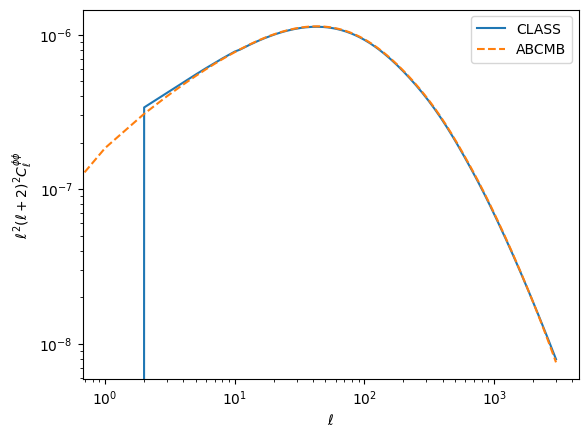

In [31]:
plt.plot(class_ell, (class_ell*(class_ell+1))**2 * class_pp, label="CLASS")
plt.plot(class_ell, (class_ell*(class_ell+1))**2 * abcmb_pp, "--", label="ABCMB")
plt.legend()
plt.xscale("log")
plt.yscale("log")
#plt.xlim((2, 2000))
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell^2(\ell+2)^2C_\ell^{\phi\phi}$")
plt.show()

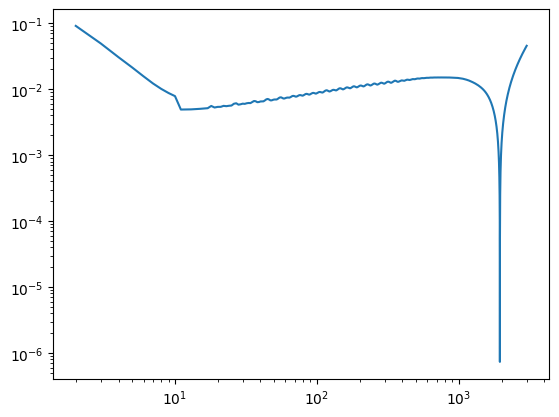

In [32]:
plt.plot(class_ell, abs(class_pp - abcmb_pp)/class_pp)
plt.xscale("log")
plt.yscale("log")
#plt.xlim((2, 2000))
plt.show()

## Temperature Cl

$$
C_\ell = \int_{0.98}^{1} \xi(\beta) J_0(\ell \beta) d\cos{\beta}
$$

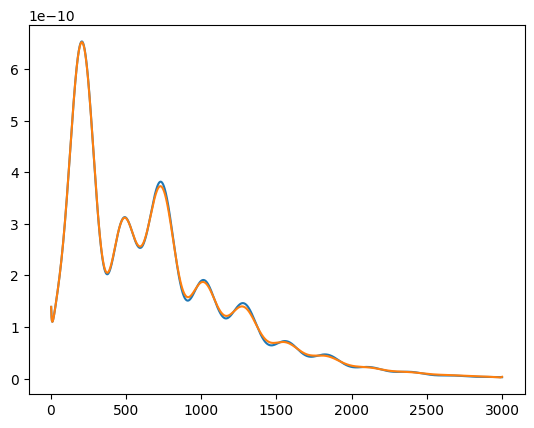

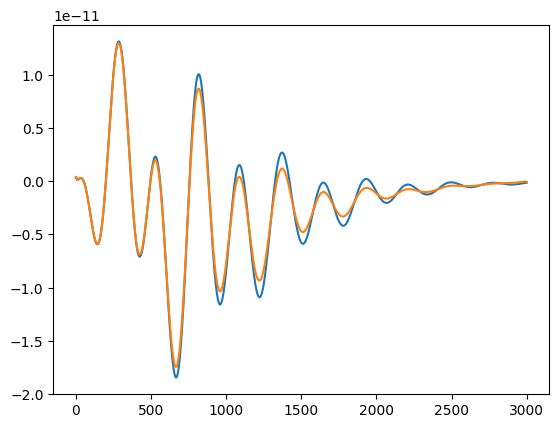

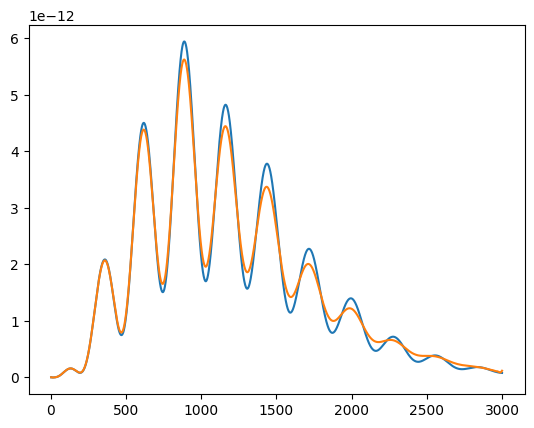

In [36]:
#res = SS.lense_ClTT(class_ell[2:], class_pp[2:], class_ell[2:]*(class_ell[2:]+1)*class_tt[2:]/2./jnp.pi)
#plt.loglog(class_ell[2:], class_ell[2:]*(class_ell[2:]+1)*res)
#ells = jnp.arange(2, 2000)
ells = class_ell[2:]
cltt = class_tt[2:]
clte = class_te[2:]
clee = class_ee[2:]
clpp = class_pp[2:]
pref = ells*(ells+1)/2./jnp.pi
#clpp = jnp.zeros(ells.size)
res_tt, res_te, res_ee = eqx.filter_jit(SS.lensed_Cls)(ells, cltt, clte, clee, PT, BG)
plt.plot(ells, pref*cltt)
plt.plot(ells, pref*(res_tt+cltt))
plt.show()

plt.plot(ells, pref*clte)
plt.plot(ells, pref*(res_te+clte))
plt.show()

plt.plot(ells, pref*clee)
plt.plot(ells, pref*(res_ee+clee))
plt.show()

In [47]:
f = eqx.filter_jit(SS.lensed_Cls)
for i in range(2):
    s = time.time()
    res_tt, res_te, res_ee = f(ells, cltt, clte, clee, PT, BG)
    res_tt.block_until_ready()
    print(time.time() - s)

16.553486347198486
11.142034769058228


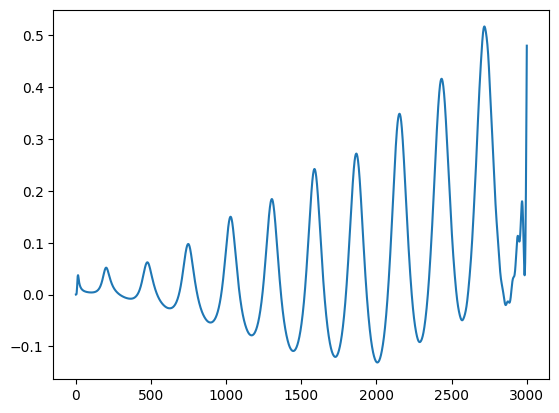

In [304]:
#plt.plot(ells, res_tt/cltt)
#plt.plot(ells, res_te/clte)
plt.plot(ells, res_ee/clee)
plt.show()

## Wigner Matrices

In [104]:
f = jit(tools.lensing_d00)
betas = jnp.linspace(0, jnp.pi/16., 1000)
l     = jnp.arange(2, 1003)
mu    = jnp.cos(betas)
print(f(mu, l).shape)

(1000, 1001)


In [55]:
betas = jnp.linspace(0, jnp.pi/16., 1000)
l     = jnp.arange(2, 1000)
mu    = jnp.cos(betas)

d00  = tools.lensing_d00(mu, l)
d11  = tools.lensing_d11(mu, l)
d1m1 = tools.lensing_d1m1(mu, l)
d2m2 = tools.lensing_d2m2(mu, l)

In the large $\ell$ limit, the Wigner matrices approach Bessel J functions as
$$
\lim_{\ell\rightarrow \infty}d_{mn}^{\ell}(\beta) \longrightarrow (-1)^{n-m} J_{m-n}(\ell \beta)\, .
$$
It serves to check the asymptotic behavior to make sure the recursion relations were correct.

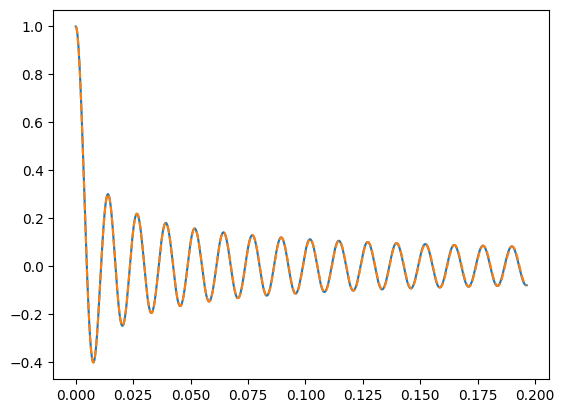

In [19]:
l = 500
plt.plot(betas, d00[:, l-2])
plt.plot(betas, scipy.special.jv(0, l*betas), "--")
plt.show()

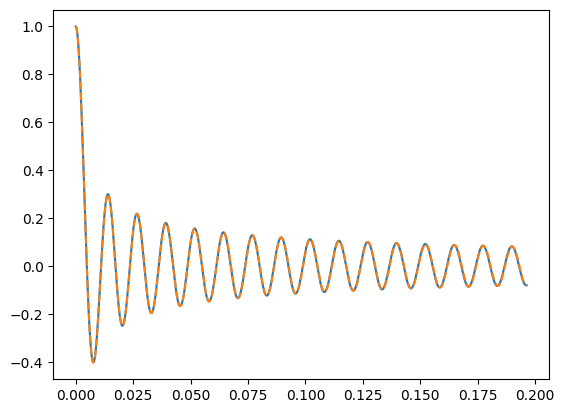

In [20]:
l = 500
plt.plot(betas, d11[:, l-2], label="d11")
plt.plot(betas, scipy.special.jv(0, l*betas), "--")
plt.show()

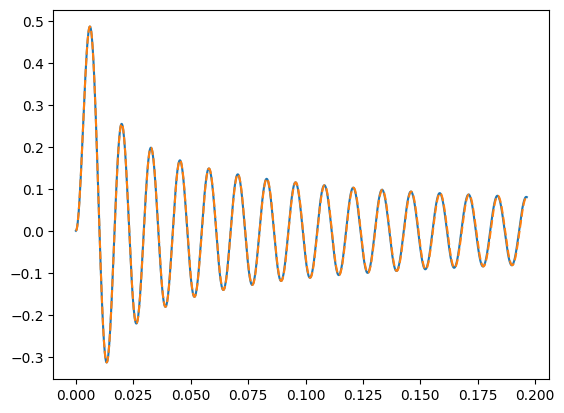

In [21]:
l = 500
plt.plot(betas, d1m1[:, l-2], label="d1m1")
plt.plot(betas, scipy.special.jv(2, l*betas), "--")
plt.show()

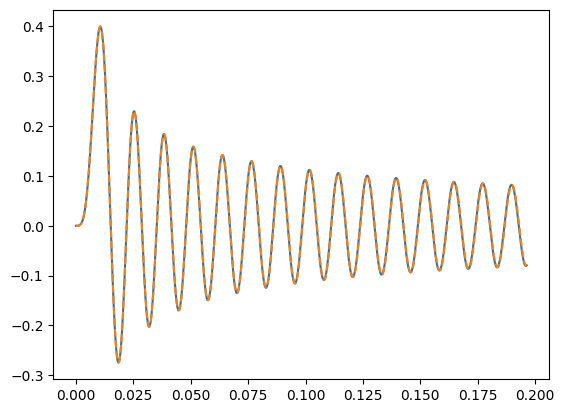

In [62]:
l = 500
plt.plot(betas, d2m2[:, l-2], label="d1m1")
plt.plot(betas, scipy.special.jv(4, l*betas), "--")
plt.show()

In [233]:
# Attempt at general solution
def wigner_d_matrix(mu, ells, m, n):
    """
    m, n are integers. m must be positive and greater than n.
    ells an array ([m, m+1, m+2, ..., ellmax])
    """
    
    # base case: ell = m
    def base_val(mu):
        beta = jnp.arccos(mu)
        norm = jnp.sqrt((2*m+1)/2) * jnp.sqrt(factorial(2*m)/(factorial(m+n)*factorial(m-n)))
        return norm * jnp.cos(beta/2.)**(m+n)*(-jnp.sin(beta/2.))**(m-n)
        #return norm * jnp.sqrt((1+mu)/2)**(m+n) * jnp.sqrt((1-mu)/2)**(m-n)

    normA = jnp.sqrt((2*ells+3)/(2*ells+1))
    normC = jnp.sqrt((2*ells+3)/(2*ells-1))
    denom = jnp.sqrt((ells+1)**2-m**2) * jnp.sqrt((ells+1)**2-n**2)
    A = jnp.nan_to_num(normA * (ells+1)*(2*ells+1) / denom, 0)
    B = jnp.nan_to_num(-A * m * n / ells / (ells+1), 0)
    C = jnp.nan_to_num(-normC * jnp.sqrt(ells**2-m**2) * jnp.sqrt(ells**2-n**2) / denom * (ells+1)/ells, 0)

    def one_mu(mu):
        d_start = base_val(mu) # Corresponds to ellmin = m
                
        def recursive_dlp1(carry, inputs):
            # For the first iteration, will take d1 and d2, compute d3.
            dl, dlm1 = carry 
            a, b, c = inputs

            # Compute dlp1
            dlp1 = a*mu*dl + b*dl + c*dlm1

            # Save dl, then make dl->dlm1, dlp1->dl
            return (dlp1, dl), dl

        # run scan for l = 2..lmax-1
        (_, _), res = lax.scan(recursive_dlp1, (d_start, 0.), (A, B, C))
        return res * jnp.sqrt(2./(2.*ells+1))

    return vmap(one_mu)(mu)

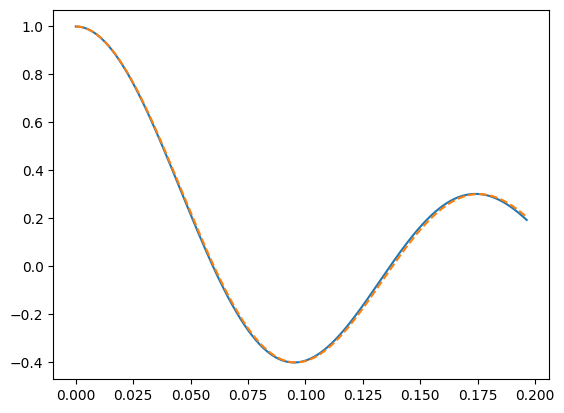

In [245]:
m = 4
n = 4
betas = jnp.linspace(0, jnp.pi/16., 1000)
l     = jnp.arange(m, 1000)
mu    = jnp.cos(betas)
d = jit(wigner_d_matrix)(mu, l, m, n)

l_plot = 10*m
plt.plot(betas, d[:, l_plot-m])
plt.plot(betas, (-1)**(n-m)*scipy.special.jv(m-n, l_plot*betas), "--")
plt.show()

In [248]:
d.shape
zeros = jnp.zeros((mu.size, m-2))
d_patched = jnp.concatenate((zeros, d), axis=1)

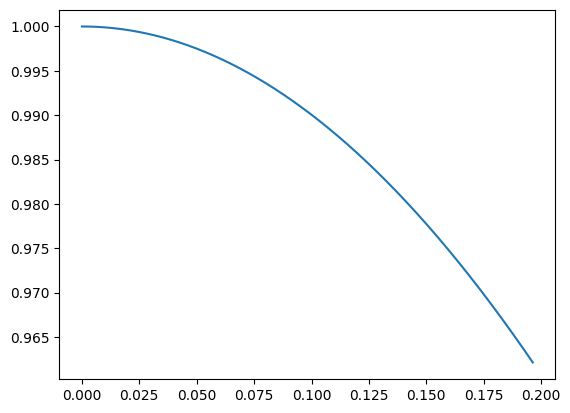

In [252]:
plt.plot(betas, d_patched[:, 2])

In [280]:
arr = jnp.ones(5)

5